# 1. Quickstart: the temperature power spectrum of a masked sky

This notebook measures the angular power spectrum $C_\ell$ of a CMB temperature map observed on
part of the sky, with the **pseudo-$C_\ell$ (MASTER)** method as implemented by NaMaster, running
on a GPU with GMaster.

**What you will do**

1. simulate a CMB temperature map from a CAMB power spectrum,
2. build a mask (Galactic cut + point-source holes) and apodize it,
3. compute the decoupled, binned power spectrum with `NmtField`, `NmtBin` and `NmtWorkspace`,
4. compare it with the theory, convolved with the exact bandpower window functions.

**The method in one paragraph.** Masking a map multiplies it by $w(\hat n)$, which couples
multipoles: the power spectrum of the masked map, the *pseudo*-$C_\ell$
$\tilde C_\ell = \frac{1}{2\ell+1}\sum_m |\tilde a_{\ell m}|^2$, satisfies
$\langle \tilde C_\ell\rangle = \sum_{\ell'} M_{\ell\ell'} C_{\ell'}$, where the mode-coupling
matrix $M$ depends only on the mask. MASTER inverts the *binned* coupling matrix to obtain unbiased
bandpowers. GMaster computes $\tilde a_{\ell m}$ (spherical-harmonic transforms) and $M$ on the GPU.

`import gmaster as nmt` is a drop-in replacement for `import pymaster as nmt`: every call below is
valid NaMaster code.

In [1]:
import os
os.environ.setdefault("JAX_ENABLE_X64", "1")   # NaMaster-level double precision; set before importing JAX

import time
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import jax
import gmaster as nmt

print("GMaster", nmt.__version__, "| JAX", jax.__version__, "| device:", jax.devices()[0].device_kind)

GMaster 1.0.0 | JAX 0.10.0 | device: NVIDIA RTX PRO 6000 Blackwell Workstation Edition


## Theory spectrum and a simulated map

We use CAMB for a Planck-2018-like $\Lambda$CDM model and draw a Gaussian realisation with
`healpy.synfast`. The band limit of a HEALPix map is $\ell_{\max} = 3N_{\rm side}-1$.

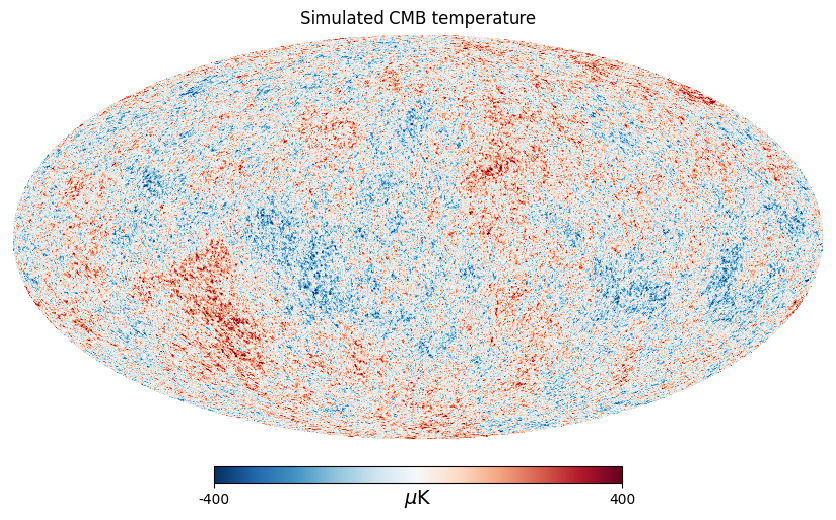

In [2]:
import camb

def camb_spectra(lmax, r=0.0):
    """Lensed CMB C_ell in muK^2 (TT, EE, BB, TE) for a Planck-2018-like cosmology, ell = 0..lmax."""
    pars = camb.set_params(H0=67.4, ombh2=0.0224, omch2=0.120, mnu=0.06, omk=0, tau=0.054,
                           As=2.1e-9, ns=0.965, r=r, lmax=lmax + 500, WantTensors=r > 0)
    res = camb.get_results(pars)
    cl = res.get_cmb_power_spectra(pars, CMB_unit="muK", raw_cl=True, lmax=lmax)["total"]
    return {k: cl[:, i] for i, k in enumerate(["TT", "EE", "BB", "TE"])}

nside = 512
lmax = 3 * nside - 1
ell = np.arange(lmax + 1)
cl = camb_spectra(lmax)

np.random.seed(1234)
cmb_T = hp.synfast(cl["TT"], nside, lmax=lmax, new=True)
hp.mollview(cmb_T, title="Simulated CMB temperature", unit=r"$\mu$K", cmap="RdBu_r", min=-400, max=400)

## A realistic mask

A $|b| < 20^\circ$ Galactic cut plus 200 circular holes of radius $0.5^\circ$ standing in for point
sources. Sharp edges spread power across all multipoles, so the binary mask is **apodized**: its
edges are smoothed over 1 degree with NaMaster's C1 taper (`mask_apodization`, aposize in degrees).

observed sky fraction f_sky = 0.641


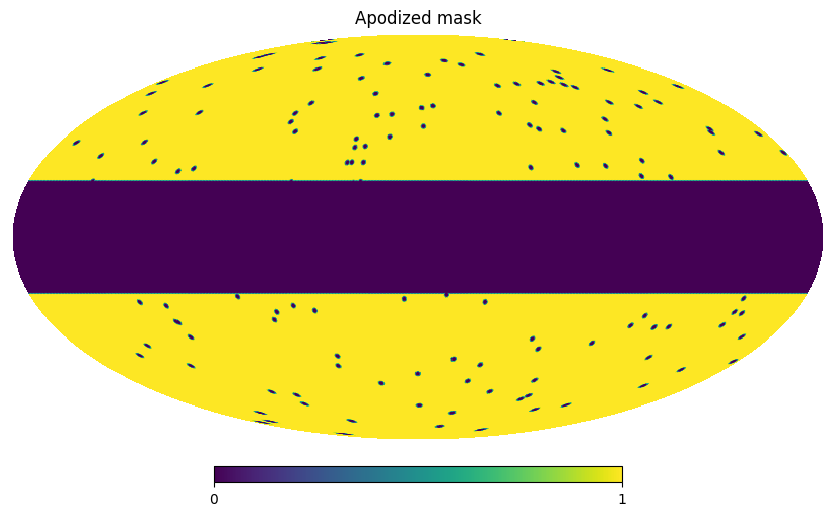

In [3]:
theta, phi = hp.pix2ang(nside, np.arange(hp.nside2npix(nside)))
galactic_latitude = 90.0 - np.degrees(theta)
binary = (np.abs(galactic_latitude) > 20.0).astype(float)

rng = np.random.default_rng(0)
for vec in hp.ang2vec(np.arccos(rng.uniform(-1, 1, 200)), rng.uniform(0, 2 * np.pi, 200)):
    binary[hp.query_disc(nside, vec, np.radians(0.5))] = 0.0

mask = np.asarray(nmt.mask_apodization(binary, 1.0, apotype="C1"))
print(f"observed sky fraction f_sky = {mask.mean():.3f}")
hp.mollview(mask, title="Apodized mask", cmap="viridis")

## Fields, bins and the coupling matrix

* `NmtField(mask, [map])` stores the mask and computes the harmonic coefficients of the masked map
  (spin 0 for a single map). `n_iter` Jacobi iterations (default 3) refine the HEALPix analysis.
* `NmtBin.from_nside_linear(nside, 16)` groups multipoles into bandpowers of width 16 up to the
  band limit. HEALPix quadrature is accurate below about $\ell = 2N_{\rm side}$; above it,
  NaMaster and GMaster alike lose up to ~10% of the power near $3N_{\rm side}$, so analyses use
  the bandpowers below $2N_{\rm side}$.
* `NmtWorkspace.from_fields(f, f, bins)` computes the mode-coupling matrix of the mask and its binned
  inverse. It depends only on the masks, so it can be reused for any map with the same mask
  (see tutorial 3).

The first call of each function compiles its GPU kernels (JAX just-in-time compilation), so we time
the pipeline twice.

In [4]:
bins = nmt.NmtBin.from_nside_linear(nside, 16)
ell_eff = np.asarray(bins.get_effective_ells())

def estimate(mask, maps, bins):
    field = nmt.NmtField(mask, maps)
    workspace = nmt.NmtWorkspace.from_fields(field, field, bins)
    cl_coupled = nmt.compute_coupled_cell(field, field)
    return workspace, np.asarray(workspace.decouple_cell(cl_coupled))   # np.asarray waits for the GPU

for label in ("first call (includes compilation)", "second call"):
    t0 = time.perf_counter()
    workspace, cl_hat = estimate(mask, [cmb_T], bins)
    print(f"{label}: {time.perf_counter() - t0:.2f} s")
print("decoupled spectra:", cl_hat.shape, "(n_cls, n_bandpowers)")

first call (includes compilation): 4.69 s
second call: 0.02 s
decoupled spectra: (1, 95) (n_cls, n_bandpowers)


## Comparison with theory

The expectation of each bandpower is not simply the theory averaged over the bin: it is the theory
multiplied by the **bandpower window functions** $\mathcal{B}_{b\ell}$, which include the effect of
the mask and the binning. `workspace.get_bandpower_windows()` returns them with shape
`(n_cls, n_bandpowers, n_cls, lmax+1)`.

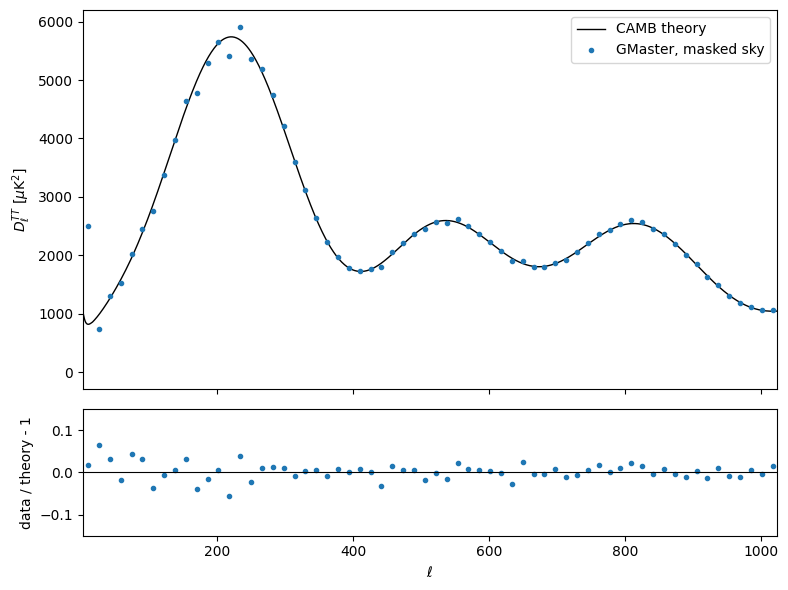

In [5]:
windows = np.asarray(workspace.get_bandpower_windows())
cl_theory_binned = np.einsum("ibjl,jl->ib", windows, cl["TT"][None, :])

keep = ell_eff < 2 * nside          # HEALPix quadrature is accurate below ~2 nside
dl = ell_eff * (ell_eff + 1) / (2 * np.pi)
fig, (ax, axr) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax.plot(ell[:2 * nside + 1], (ell * (ell + 1) * cl["TT"] / (2 * np.pi))[:2 * nside + 1], "k-", lw=1, label="CAMB theory")
ax.plot(ell_eff[keep], (dl * cl_hat[0])[keep], "o", ms=3, color="C0", label="GMaster, masked sky")
ax.set_ylabel(r"$D_\ell^{TT}$ [$\mu$K$^2$]")
ax.legend()
axr.plot(ell_eff[keep], (cl_hat[0] / cl_theory_binned[0] - 1)[keep], "o", ms=3, color="C0")
axr.axhline(0, color="k", lw=0.8)
axr.set_ylim(-0.15, 0.15)
axr.set_xlabel(r"$\ell$")
axr.set_ylabel("data / theory - 1")
ax.set_xlim(2, 2 * nside)
plt.tight_layout()

The scatter in the lower panel is cosmic variance: one sky realisation, observed on
$f_{\rm sky}\approx 0.6$. There is no bias, because MASTER has removed the mode coupling exactly.
Tutorial 3 shows how to compute the error bars (Gaussian covariance) and checks them against
simulations.

## One-line version

NaMaster's `compute_full_master` runs the whole estimator in one call:

In [6]:
cl_full = np.asarray(nmt.compute_full_master(nmt.NmtField(mask, [cmb_T]), nmt.NmtField(mask, [cmb_T]), bins))
print("identical to the step-by-step result:", np.allclose(cl_full, cl_hat))

identical to the step-by-step result: True


## Next steps

* **Tutorial 2** – polarization: E and B modes, E-to-B leakage and B-mode purification.
* **Tutorial 3** – reusing workspaces for simulations, and Gaussian covariance matrices.
* **Tutorial 4** – contaminant deprojection and beams.
* **Tutorial 5** – cross-check against NaMaster, performance, and settings for large maps.